In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# LOAD EXCEL WORKBOOK
# =========================================================

excel_file = "TrainingData.xlsx"

# Read all sheets
xls = pd.ExcelFile(excel_file)

print("Available Sheets:")
print(xls.sheet_names)

# =========================================================
# LOAD EACH MODEL SHEET
# =========================================================

baseline_bn = pd.read_excel(excel_file, sheet_name='Baseline U-Net')
batch_norm = pd.read_excel(excel_file, sheet_name='+Batch Normalization')
deep_unet = pd.read_excel(excel_file, sheet_name='+ Deep U-Net')
aspp = pd.read_excel(excel_file, sheet_name='+ ASPP')
ag = pd.read_excel(excel_file, sheet_name='+ AG')
enhanced = pd.read_excel(excel_file, sheet_name='Hybride BCE Dice')
deep_lab3 = pd.read_excel(excel_file, sheet_name='DeepLab3')
hrnet = pd.read_excel(excel_file, sheet_name='HRNet')

Available Sheets:
['Baseline U-Net', '+Batch Normalization', '+ Deep U-Net', '+ AG', '+ ASPP', 'Hybride BCE Dice', 'DeepLab3', 'HRNet']


In [54]:
# =========================================================
# FUNCTION TO COMPUTE F1 AND IoU
# =========================================================

def compute_metrics(df):

    # ---- Training F1 ----
    df['f1'] = (
        2 * df['precision'] * df['recall']
    ) / (
        df['precision'] + df['recall'] + 1e-7
    )

    # ---- Validation F1 ----
    df['val_f1'] = (
        2 * df['val_precision'] * df['val_recall']
    ) / (
        df['val_precision'] + df['val_recall'] + 1e-7
    )

    # ---- IoU from F1 ----
    df['iou'] = df['f1'] / (2 - df['f1'] + 1e-7)

    df['val_iou'] = (
        df['val_f1'] / (2 - df['val_f1'] + 1e-7)
    )

    return df

In [55]:
# =========================================================
# COMPUTE METRICS FOR ALL SHEETS
# =========================================================

baseline_bn = compute_metrics(baseline_bn)
batch_norm = compute_metrics(batch_norm)
deep_unet = compute_metrics(deep_unet)
aspp = compute_metrics(aspp)
ag = compute_metrics(ag)
enhanced = compute_metrics(hybrid)
deep_lab3 = compute_metrics(deep_lab3)
hrnet = compute_metrics(hrnet)

In [56]:
# =========================================================
# STORE MODELS IN A LIST
# =========================================================

models = [
    (baseline_bn, 'Baseline U-Net'),
    (batch_norm, 'Batch Normalization'),
    (deep_unet, 'Deep U-Net'),
    (aspp, 'ASPP'),
    (ag, 'AG'),
    (enhanced, 'Enhanced Unet'),
    (deep_lab3, 'DeepLab3'),
    (hrnet, 'HRNet')
]


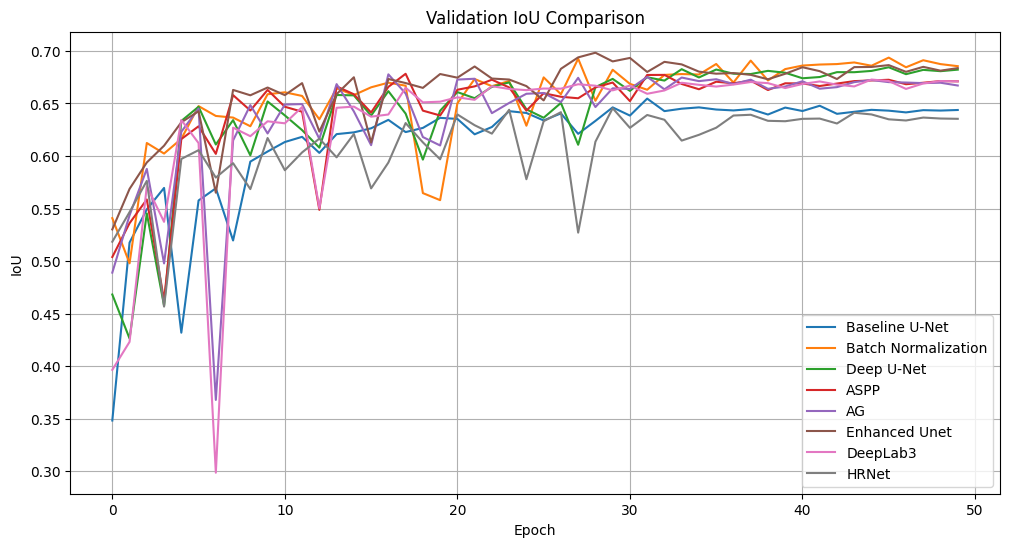

In [57]:
# =========================================================
# PLOT VALIDATION IoU
# =========================================================

plt.figure(figsize=(12,6))

for df, name in models:
    plt.plot(df['epoch'], df['val_iou'], label=name)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU Comparison")
plt.legend()
plt.grid(True)
plt.savefig(
    "MIT_Validation_IoU.png",
    dpi=300,
    bbox_inches='tight')
plt.show()

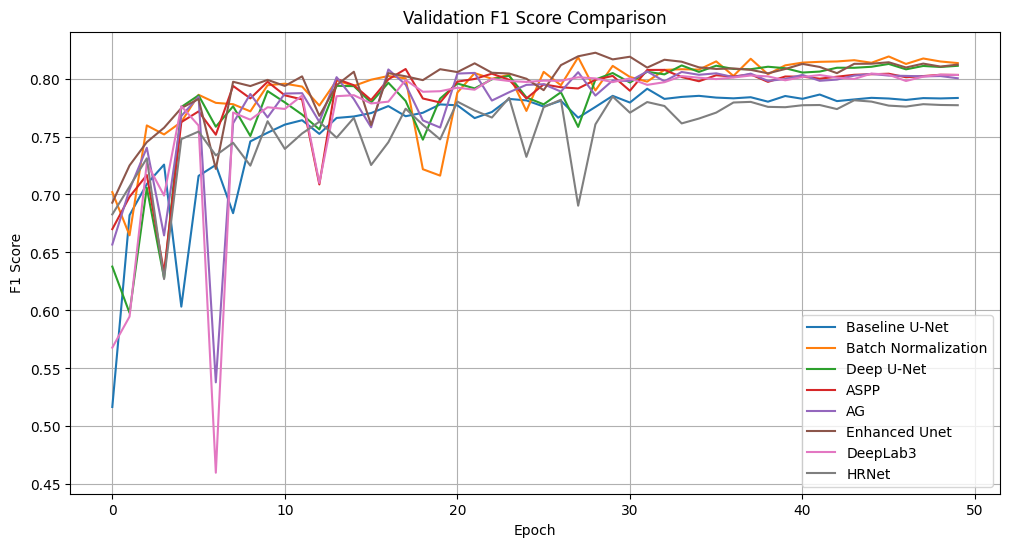

In [58]:
# =========================================================
# PLOT VALIDATION F1 SCORE
# =========================================================

plt.figure(figsize=(12,6))

for df, name in models:
    plt.plot(df['epoch'], df['val_f1'], label=name)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 Score Comparison")
plt.legend()
plt.grid(True)
plt.savefig(
    "MIT_Validation_F1_Score.png",
    dpi=300,
    bbox_inches='tight')
plt.show()


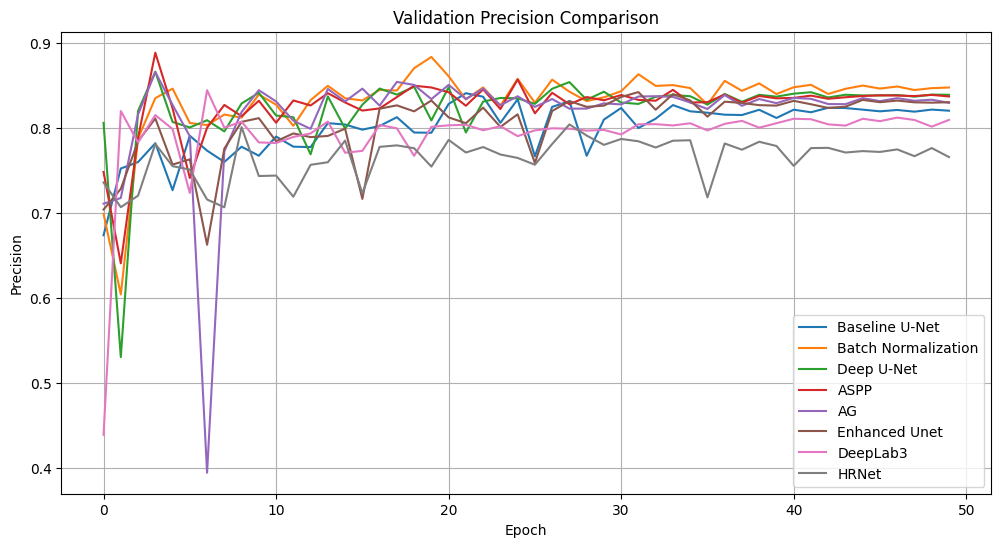

In [59]:
# =========================================================
# PLOT VALIDATION PRECISION
# =========================================================

plt.figure(figsize=(12,6))

for df, name in models:
    plt.plot(df['epoch'], df['val_precision'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Validation Precision Comparison")
plt.legend()
plt.grid(True)
plt.savefig(
    "MIT_Validation_Precision.png",
    dpi=300,
    bbox_inches='tight')
plt.show()

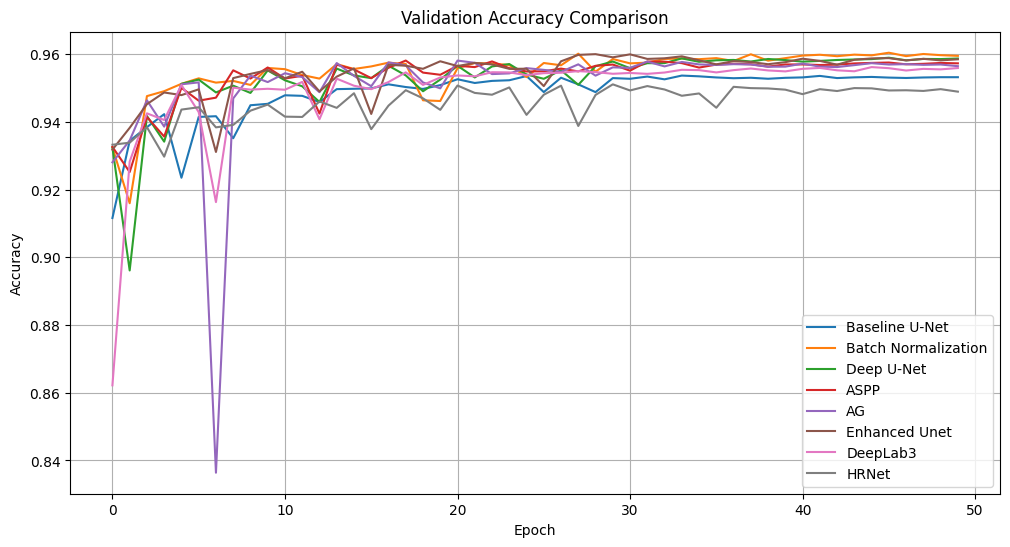

In [60]:
# =========================================================
# PLOT VALIDATION ACCURACY
# =========================================================

plt.figure(figsize=(12,6))

for df, name in models:
    plt.plot(df['epoch'], df['val_accuracy'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
# SAVE FIGURE
plt.savefig(
    "MIT_Validation_Accuracy.png",
    dpi=300,
    bbox_inches='tight')
plt.show()
